In [1]:
# Gerekli araçları (kütüphaneleri) çağırıyoruz
import pandas as pd
import numpy as np

# Veri setini bilgisayardan okuyoruz
df = pd.read_csv("mushrooms.csv")

# Tablonun ilk 5 satırını ekrana yazdırıyoruz
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
# 1. Veri setinin tam olarak kaç satır ve sütundan oluştuğunu görelim
print("Veri Seti Boyutu (Satır, Sütun):", df.shape)

# 2. Verideki kategorik harflerin genel bir istatistiksel özeti
print("\nİstatistiksel Özet:")
print(df.describe().T) # Daha rahat okunması için tersini (.T) alıyoruz

# 3. Gizli eksik verileri yakalama:
# Bu veri setinde eksik/bilinmeyen veriler '?' işareti ile girilmiştir.
# Bilgisayarın bunu "boş veri" olarak algılaması için '?' işaretlerini standart "NaN" formatına çeviriyoruz.
df.replace('?', np.nan, inplace=True)

# 4. Hangi sütunda kaç tane eksik (boş) veri var, net listesini çıkaralım
print("\nSütunlara Göre Eksik Veri Sayıları:")
print(df.isnull().sum())

Veri Seti Boyutu (Satır, Sütun): (8124, 23)

İstatistiksel Özet:
                         count unique top  freq
class                     8124      2   e  4208
cap-shape                 8124      6   x  3656
cap-surface               8124      4   y  3244
cap-color                 8124     10   n  2284
bruises                   8124      2   f  4748
odor                      8124      9   n  3528
gill-attachment           8124      2   f  7914
gill-spacing              8124      2   c  6812
gill-size                 8124      2   b  5612
gill-color                8124     12   b  1728
stalk-shape               8124      2   t  4608
stalk-root                8124      5   b  3776
stalk-surface-above-ring  8124      4   s  5176
stalk-surface-below-ring  8124      4   s  4936
stalk-color-above-ring    8124      9   w  4464
stalk-color-below-ring    8124      9   w  4384
veil-type                 8124      1   p  8124
veil-color                8124      4   w  7924
ring-number            

Verideki toplam eksik veri sayısı: 0


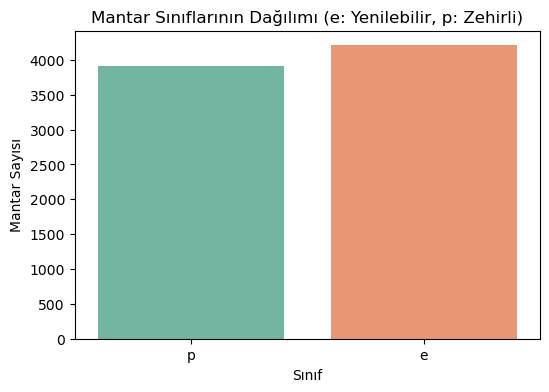

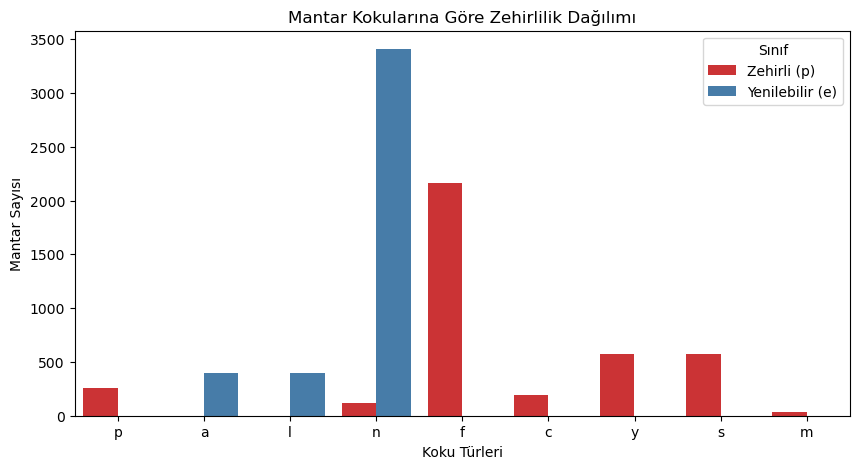

In [4]:
# 1. Eksik Verileri Doldurma (Imputation)
# stalk-root sütunundaki boş değerleri 'm' (missing) harfi ile dolduruyoruz
df['stalk-root'] = df['stalk-root'].fillna('m')

# Kontrol edelim, veri setinde hiç boş değer kaldı mı?
print("Verideki toplam eksik veri sayısı:", df.isnull().sum().sum())

# 2. VERİ GÖRSELLEŞTİRME (Hocanın İstediği Grafikler)
# Grafiklerin şık görünmesi için seaborn stilini ayarlıyoruz
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik 1: Hedef Değişkenin Dağılımı (Mantar Sayıları)
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, hue='class', palette='Set2', legend=False)
plt.title('Mantar Sınıflarının Dağılımı (e: Yenilebilir, p: Zehirli)')
plt.xlabel('Sınıf')
plt.ylabel('Mantar Sayısı')
plt.show()

# Grafik 2: Koku Özelliğine Göre Zehirlilik Durumu (En Belirgin Özellik)
plt.figure(figsize=(10,5))
sns.countplot(x='odor', hue='class', data=df, palette='Set1')
plt.title('Mantar Kokularına Göre Zehirlilik Dağılımı')
plt.xlabel('Koku Türleri')
plt.ylabel('Mantar Sayısı')
plt.legend(title='Sınıf', labels=['Zehirli (p)', 'Yenilebilir (e)'])
plt.show()

In [5]:
# 3. KATEGORİK VERİLERİ SAYISAL DEĞERLERE ÇEVİRME (ENCODING)
# Python'un scikit-learn kütüphanesinden LabelEncoder aracını çağırıyoruz
from sklearn.preprocessing import LabelEncoder

# Veri setimizin bir kopyasını oluşturuyoruz (orijinali bozulmasın diye)
df_encoded = df.copy()
le = LabelEncoder()

# Döngü yardımıyla tablodaki 23 sütunun hepsini tek tek sayılara çeviriyoruz
for sutun in df_encoded.columns:
    df_encoded[sutun] = le.fit_transform(df_encoded[sutun])

# Bakalım harfler sayıya dönüşmüş mü? İlk 5 satırı kontrol edelim:
df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [6]:
# 4. VERİYİ EĞİTİM VE TEST OLARAK AYIRMA (TRAIN-TEST SPLIT)
# Sklearn kütüphanesinden bölme aracını çağırıyoruz
from sklearn.model_selection import train_test_split

# Hedef değişkenimizi (class) ve bağımsız değişkenlerimizi (özellikleri) ayırıyoruz
# y = Tahmin etmek istediğimiz sütun (Sınıf: Zehirli mi / Yenilebilir mi)
# X = Geri kalan tüm fiziksel özellik sütunları (class dışındaki 22 sütun)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Veriyi %80 Eğitim (Train) ve %20 Test olarak bölüyoruz
# random_state=42 veriyoruz ki kodu her çalıştırdığımızda aynı rastgelelikle bölünsün, sonuçlar değişmesin
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bölme işleminin sonuçlarını ekrana yazdırıp kontrol edelim
print("Eğitim kümesindeki mantar sayısı (X_train):", X_train.shape[0])
print("Test kümesindeki mantar sayısı (X_test):", X_test.shape[0])

Eğitim kümesindeki mantar sayısı (X_train): 6499
Test kümesindeki mantar sayısı (X_test): 1625


--- DECISION TREE (KARAR AĞACI) PERFORMANSI ---
Accuracy (Doğruluk): 1.0000
Precision (Kesinlik): 1.0000
Recall (Duyarlılık): 1.0000
F1-Score: 1.0000

--- RANDOM FOREST (RASTGELE ORMAN) PERFORMANSI ---
Accuracy (Doğruluk): 1.0000
Precision (Kesinlik): 1.0000
Recall (Duyarlılık): 1.0000
F1-Score: 1.0000



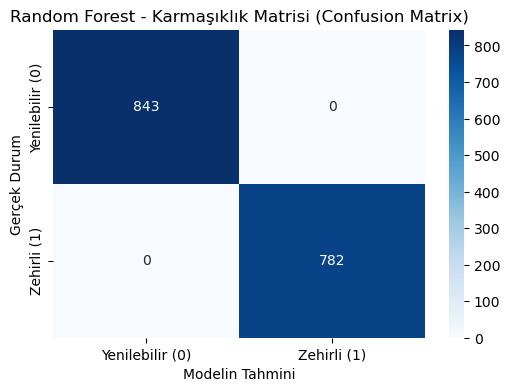

In [7]:
# 5. MODEL KURULUMU VE EĞİTİMİ
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Modelleri tanımlıyoruz
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Modelleri 'Eğitim' (Train) verileriyle eğitiyoruz (Sistemin öğrenme aşaması)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Eğitilen modellere daha önce hiç görmedikleri 'Test' verilerini tahmin ettiriyoruz (Sınav aşaması)
dt_tahminler = dt_model.predict(X_test)
rf_tahminler = rf_model.predict(X_test)

# 6. MODEL DEĞERLENDİRME (Hocanın İstediği Metrikler)
print("--- DECISION TREE (KARAR AĞACI) PERFORMANSI ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, dt_tahminler):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, dt_tahminler):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, dt_tahminler):.4f}")
print(f"F1-Score: {f1_score(y_test, dt_tahminler):.4f}\n")

print("--- RANDOM FOREST (RASTGELE ORMAN) PERFORMANSI ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, rf_tahminler):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, rf_tahminler):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, rf_tahminler):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_tahminler):.4f}\n")

# Hoca için özel puan getirici: Random Forest Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
cm = confusion_matrix(y_test, rf_tahminler)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Yenilebilir (0)', 'Zehirli (1)'], yticklabels=['Yenilebilir (0)', 'Zehirli (1)'])
plt.title('Random Forest - Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.show()